# LAB1 — Docling: Ingestão Avançada de PDFs Jurídicos

## Objetivos da Aula
1. **Processar PDFs técnicos** com tabelas aninhadas e imagens usando Docling
2. **Inspecionar o Document Object** e extrair estruturas complexas
3. **Exportar para Markdown** preservando formatação hierárquica
4. **Comparar com baseline (PyPDF2)** para demonstrar vantagens
5. **Integrar com LangChain Documents** para pipeline RAG

---

## Pipeline Completo do Docling (5 Estágios)

```
┌─────────────────────────────────────────────────────────────────┐
│                    PIPELINE DOCLING COMPLETO                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  [1] ENTRADA PDF                                               │
│      └─> Arquivo .pdf (escanado ou nativo)                     │
│                                                                 │
│  [2] CONVERSÃO DOCLING                                         │
│      ├─> OCR (if do_ocr=True)      [opcional, lento]          │
│      ├─> Detecção de Tabelas       [se do_table_structure=T]  │
│      ├─> Detecção de Layout        [headers, footers, seções] │
│      └─> Análise de Figuras        [se do_figure_detection=T] │
│                                                                 │
│  [3] DOCUMENT OBJECT                                           │
│      ├─> doc.document.children     [lista de elementos]       │
│      ├─> doc.tables                [tabelas estruturadas]     │
│      └─> doc.metadata              [título, autor, etc]       │
│                                                                 │
│  [4] EXPORT MARKDOWN                                           │
│      ├─> Headers # ## ###          [hierarquia preservada]    │
│      ├─> Tabelas Markdown          [| Col1 | Col2 |]          │
│      └─> Inline formatting         [**bold**, *italic*]       │
│                                                                 │
│  [5] INTEGRAÇÃO RAG                                            │
│      ├─> Splitter (por header)     [MarkdownHeaderTextSplit]  │
│      ├─> Chunks com metadados      [fonte, seção, tipo]       │
│      └─> LangChain Documents       [pronto para embedding]    │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

---

## Referências
- **ABNT NBR ISO/IEC 27001:2022** — Gestão de segurança da informação
- **Docling Documentation**: https://github.com/DS4SD/docling
- **LangChain TextSplitter**: https://python.langchain.com/docs/modules/data_connection/document_transformers/
- **Markdown RFC 7763**: https://www.rfc-editor.org/rfc/rfc7763.txt

In [2]:
# [CÉLULA 1] Instalação de dependências
# Instalar biblioteca Docling para processamento de PDFs
!pip install docling
# Instalar LangChain e integrações
!pip install langchain langchain-community langchain-text-splitters
# Instalar sentence-transformers para embeddings
!pip install sentence-transformers
# Instalar reportlab para gerar PDFs de teste
!pip install reportlab
# Instalar pandas para análise de dados
!pip install pandas
# Instalar matplotlib para visualizações
!pip install matplotlib

# Importar bibliotecas principais
import os
import sys
from pathlib import Path
from datetime import datetime
import time
import json

# Importar PyPDF2 para comparação baseline
!pip install PyPDF2
import PyPDF2

# Importar Docling
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

# Importar LangChain
from langchain_core.documents import Document
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

# Importar utilitários
import pandas as pd
import matplotlib.pyplot as plt
from reportlab.lib.pagesizes import A4, letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm, inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, PageBreak
from reportlab.lib import colors

# Exibir versões das bibliotecas
print("\n=== Versões das Bibliotecas ===")
import docling
import langchain
print(f"Docling: {docling.__version__ if hasattr(docling, '__version__') else 'N/A'}")
print(f"LangChain: {langchain.__version__}")
print(f"Python: {sys.version}")
print("\nTodas as dependências instaladas com sucesso!")


d:\IBMEC\MBA_RAG_CAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Versões das Bibliotecas ===
Docling: N/A
LangChain: 1.3.1
Python: 3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]

Todas as dependências instaladas com sucesso!


## Teoria: O Problema que Docling Resolve

### PyPDF2 vs Docling

Ao processar um PDF com tabela, as duas bibliotecas produzem saídas **radicalmente diferentes**:

```
EXEMPLO: PDF com tabela 3x3 (Crime | Janeiro | Fevereiro | Total)
─────────────────────────────────────────────────────────────────

┌─ PYPDF2 (extração raw) ──────────────────────────────────────┐
│ Roubo Janeiro Fevereiro Homicídio 12 8 Fraude 45 52 Tráfico  │
│ 78 91                                                        │
│                                                              │
│ PROBLEMA: Coluna layout perdido! Célula-por-célula mistura. │
│           Impossível recuperar estrutura.                   │
└──────────────────────────────────────────────────────────────┘

┌─ DOCLING (com table_structure=True) ─────────────────────────┐
│ | Crime      | Janeiro | Fevereiro | Total |                │
│ |─────────────|────────|──────────|────── |                │
│ | Roubo       | 12      | 8        | 20    |                │
│ | Homicídio   | 45      | 52       | 97    |                │
│ | Fraude      | 78      | 91       | 169   |                │
│                                                              │
│ VANTAGEM: Markdown formatado! Estrutura recuperada 100%.     │
│           Exportável para pandas DataFrame direto.           │
└──────────────────────────────────────────────────────────────┘
```

### Por que isso importa em RAG jurídico?
- **Acórdãos** com tabelas de jurisprudência
- **Relatórios policiais** com estatísticas de crime
- **Contratos** com tabelas de pagamento
- **Decisões** com quadros comparativos

**Docling preserva a semântica da tabela, não apenas a formatação.**

In [5]:
# [CÉLULA 2] Carregar os 2 PDFs reais do dataset da Aula 2
# Substitui a geração sintética por documentos REAIS do domínio Segurança Pública:
#   - Manual_DPCA_atualizado.pdf  → PDF DIGITAL com estrutura hierárquica (texto extraível)
#   - Laudo.pdf                    → PDF com IMAGEM DE TEXTO (precisa de OCR)
# Fallback: caso algum dos PDFs não esteja no datasets/, gera um PDF sintético mínimo.

from pathlib import Path
from datetime import datetime
import os, shutil

# Caminhos dos datasets (relativos ao notebook em aula2/labs/)
DATASET_DIR = (Path(__file__).parent / "../datasets").resolve() if "__file__" in dir() else Path("../datasets").resolve()
if not DATASET_DIR.exists():
    # fallback para caminho absoluto típico do venv_rag da Aula 1
    DATASET_DIR = Path.cwd().parent / "datasets"

PDF_MANUAL = DATASET_DIR / "TST_acordaos.pdf"   # PDF digital — estrutura hierárquica
PDF_LAUDO  = DATASET_DIR / "POP-INVESTIGACAO-CRIME.pdf" # PDF escaneado — caso OCR

print("="*70)
print("DATASET DA AULA 2 — PDFs reais")
print("="*70)
print(f"Dataset dir: {DATASET_DIR}")
print(f"  • TST_acordaos.pdf existe? {PDF_MANUAL.exists()}  ({PDF_MANUAL.stat().st_size//1024 if PDF_MANUAL.exists() else 0} KB)")
print(f"  • POP-INVESTIGACAO-CRIME.pdf  existe? {PDF_LAUDO.exists()}  ({PDF_LAUDO.stat().st_size//1024 if PDF_LAUDO.exists() else 0} KB)")

# Variáveis que o resto do LAB usa (mantemos os nomes históricos para não quebrar células seguintes)
# pdf_simples_path  → PDF digital com estrutura  (Manual_DPCA)
# pdf_complexo_path → PDF escaneado / caso OCR    (Laudo)
test_dir = "/tmp/pdfs_teste"
os.makedirs(test_dir, exist_ok=True)

if PDF_MANUAL.exists():
    pdf_simples_path = str(PDF_MANUAL)
    print(f"\n✓ PDF simples (digital): {pdf_simples_path}")
else:
    # Fallback — gera um PDF mínimo sintético para o LAB não quebrar
    from reportlab.platypus import SimpleDocTemplate, Paragraph
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.lib.pagesizes import A4
    pdf_simples_path = os.path.join(test_dir, "fallback_simples.pdf")
    sd = SimpleDocTemplate(pdf_simples_path, pagesize=A4)
    sd.build([Paragraph("Fallback PDF — Manual_DPCA_atualizado.pdf não encontrado no datasets/.",
                        getSampleStyleSheet()["Normal"])])
    print(f"\n⚠️  Manual_DPCA não encontrado — usando fallback sintético em {pdf_simples_path}")

if PDF_LAUDO.exists():
    pdf_complexo_path = str(PDF_LAUDO)
    print(f"✓ PDF complexo (OCR): {pdf_complexo_path}")
else:
    from reportlab.platypus import SimpleDocTemplate, Paragraph
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.lib.pagesizes import A4
    pdf_complexo_path = os.path.join(test_dir, "fallback_complexo.pdf")
    sd = SimpleDocTemplate(pdf_complexo_path, pagesize=A4)
    sd.build([Paragraph("Fallback PDF — Laudo.pdf não encontrado no datasets/.",
                        getSampleStyleSheet()["Normal"])])
    print(f"⚠️  POP-INVESTIGACAO-CRIME.pdf não encontrado — usando fallback sintético em {pdf_complexo_path}")

print(f"\nVariáveis disponíveis para as próximas células:")
print(f"  pdf_simples_path  = {pdf_simples_path}")
print(f"  pdf_complexo_path = {pdf_complexo_path}")


DATASET DA AULA 2 — PDFs reais
Dataset dir: D:\IBMEC\MBA_RAG_CAG\aula2\datasets
  • TST_acordaos.pdf existe? True  (243 KB)
  • POP-INVESTIGACAO-CRIME.pdf  existe? True  (9623 KB)

✓ PDF simples (digital): D:\IBMEC\MBA_RAG_CAG\aula2\datasets\TST_acordaos.pdf
✓ PDF complexo (OCR): D:\IBMEC\MBA_RAG_CAG\aula2\datasets\POP-INVESTIGACAO-CRIME.pdf

Variáveis disponíveis para as próximas células:
  pdf_simples_path  = D:\IBMEC\MBA_RAG_CAG\aula2\datasets\TST_acordaos.pdf
  pdf_complexo_path = D:\IBMEC\MBA_RAG_CAG\aula2\datasets\POP-INVESTIGACAO-CRIME.pdf


## Seção 3: Extração com PyPDF2 (Baseline)

Antes de usar Docling, estabelecemos um **baseline** com PyPDF2 nos dois PDFs reais:
- `TST_acordaos.pdf` (digital) — PyPDF2 consegue extrair, mas perde estrutura;
- `sistemas_controle_tcu.pdf` (escaneado) — PyPDF2 retorna texto vazio ou ruído, porque o conteúdo é IMAGEM.

Essa comparação mostra **quando** vale a pena pagar o custo do Docling em vez de usar um parser PDF simples.


In [7]:
# [CÉLULA 3] Extrair PDFs com PyPDF2 para comparação

def extrair_com_pypdf2(caminho_pdf):
    """
    Extrai texto de um PDF usando PyPDF2.
    Retorna: (texto extraído, número de páginas, tempo de execução)
    """
    inicio = time.time()  # Registrar tempo inicial
    
    # Abrir arquivo PDF em modo leitura binária
    with open(caminho_pdf, 'rb') as pdf_file:
        # Criar leitor PDF
        pdf_reader = PyPDF2.PdfReader(pdf_file)
        # Obter número total de páginas
        num_pages = len(pdf_reader.pages)
        # Inicializar string para armazenar texto
        texto_completo = ""
        
        # Iterar sobre cada página
        for page_num, page in enumerate(pdf_reader.pages):
            # Extrair texto da página
            texto_pagina = page.extract_text()
            # Adicionar número da página para rastreabilidade
            texto_completo += f"\n[=== PÁGINA {page_num + 1} ===]\n{texto_pagina}\n"
    
    # Calcular tempo decorrido
    tempo_decorrido = time.time() - inicio
    
    return texto_completo, num_pages, tempo_decorrido

print("=" * 70)
print("EXTRAÇÃO COM PYPDF2 (BASELINE)")
print("=" * 70)

# Extrair do PDF simples
print("\n[1] PDF SIMPLES (Acórdão sem tabela)\n")
texto_simples, pages_simples, tempo_simples = extrair_com_pypdf2(pdf_simples_path)
print(f"Tempo de extração: {tempo_simples:.4f}s")
print(f"Número de páginas: {pages_simples}")
print(f"Caracteres extraídos: {len(texto_simples)}")
print("\nPrimeiros 500 caracteres:")
print(texto_simples[:500])
print("\n" + "-" * 70 + "\n")

# Extrair do PDF complexo
print("[2] PDF COMPLEXO (Relatório com tabela)\n")
texto_complexo, pages_complexo, tempo_complexo = extrair_com_pypdf2(pdf_complexo_path)
print(f"Tempo de extração: {tempo_complexo:.4f}s")
print(f"Número de páginas: {pages_complexo}")
print(f"Caracteres extraídos: {len(texto_complexo)}")
print("\nTrecho mostrando DESORGANIZAÇÃO DA TABELA:")
# Encontrar e mostrar região da tabela
idx_tabela = texto_complexo.find('Tipo de Crime')
if idx_tabela > 0:
    print(texto_complexo[idx_tabela:idx_tabela+400])
else:
    print("Tabela não encontrada de forma clara (layout perdido!)")
    # Mostrar região próxima a onde a tabela deve estar
    print(texto_complexo[800:1200])

print("\n" + "=" * 70)
print("PROBLEMA IDENTIFICADO:")
print("  ✗ Colunas da tabela misturadas")
print("  ✗ Impossível recuperar estrutura semântica")
print("  ✗ Útil apenas para busca full-text, não para análise estruturada")
print("=" * 70)

EXTRAÇÃO COM PYPDF2 (BASELINE)

[1] PDF SIMPLES (Acórdão sem tabela)

Tempo de extração: 0.1655s
Número de páginas: 14
Caracteres extraídos: 30050

Primeiros 500 caracteres:

[=== PÁGINA 1 ===]
SELEÇÃO DE ACÓRDÃOS - TCU - PRIMEIRA CÂMARA  
JUSTIÇA DO TRABALHO  
JUNHO /2023  
 
● ATA Nº 16/2023 - PRIMEIRA CÂMARA, DE 30/5/2023, PUBLICADA NO DOU EM 
12/6/2023  
 
ACÓRDÃO Nº 4067 /2023 – TCU – PRIMEIRA CÂMARA  
GRUPO II – CLASSE I – Primeira Câmara  
TC 006.735/2022 -3.  
Natureza: Embargos de declaração (Aposentadoria).  
Órgão: Tribunal Regional do Trabalho da 3ª Região/ MG.     
Embargante: Sandra Sara Soares Pereira (611.312.456 -87). 
Representação legal: Rudi Meir

----------------------------------------------------------------------

[2] PDF COMPLEXO (Relatório com tabela)

Tempo de extração: 0.1725s
Número de páginas: 19
Caracteres extraídos: 26717

Trecho mostrando DESORGANIZAÇÃO DA TABELA:
Tabela não encontrada de forma clara (layout perdido!)
al
Brasília - DF 
2013
 

[=== PÁGI

## Seção 4: Instalação e Inicialização do Docling

Configurar o Docling com opções otimizadas para:
- **PDF nativos** (evitar OCR desnecessário)
- **Detecção de tabelas** com análise de estrutura
- **Preservação de layout** hierárquico

In [8]:
# [CÉLULA 4] Instalar Docling e configurar conversor
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

# 1. Criar conversor Docling com opções otimizadas
pipeline_options = PdfPipelineOptions(
    do_ocr=False,                    # Não usar OCR (PDF nativo, não escaneado)
    do_table_structure=True,         # Detectar e preservar estrutura de tabelas
)

# 2. Inicializar conversor com as opções acima
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

print("\n✓ Docling DocumentConverter inicializado")
print(f"\nConfigurações ativas:")
print(f"  • do_ocr: {pipeline_options.do_ocr}")
print(f"  • do_table_structure: {pipeline_options.do_table_structure}")




✓ Docling DocumentConverter inicializado

Configurações ativas:
  • do_ocr: False
  • do_table_structure: True


## Seção 5: Convertendo o PDF Digital (TST_acordaos.pdf)

Processamos primeiro o `TST_acordaos.pdf` — um documento **digital** com estrutura hierárquica (títulos, seções e parágrafos com camada de texto nativa).

Este é o caso ideal para Docling **sem OCR**: rápido, fiel à estrutura, e produz Markdown bem formatado pronto para o `MarkdownHeaderTextSplitter` (que o LAB2 vai usar).


In [9]:
# [CÉLULA 5] Processar PDF simples com Docling
import time

print("=" * 70)
print("PROCESSAMENTO COM DOCLING - PDF SIMPLES")
print("=" * 70)

# Registrar tempo inicial
inicio_docling = time.time()

# Converter PDF usando Docling
# converter.convert() retorna um ConversionResult
doc_simples_docling = converter.convert(pdf_simples_path)

# Calcular tempo decorrido
tempo_docling = time.time() - inicio_docling

# Exportar documento para Markdown (texto estruturado)
markdown_simples = doc_simples_docling.document.export_to_markdown()

# CORREÇÃO: Nova forma de contar os elementos estruturais mapeados pelo Docling
elementos_detectados = len(list(doc_simples_docling.document.iterate_items()))

print(f"\n✓ Conversão concluída em {tempo_docling:.4f}s")
print(f"\nTamanho do Markdown: {len(markdown_simples)} caracteres")
print(f"Número de elementos detectados: {elementos_detectados}") # Exibe a contagem correta
print(f"\nPrimeiros 600 caracteres do Markdown:")
print(markdown_simples[:600])
print("\n" + "-" * 70)
print("\nOBSERVAÇÕES:")
print("  ✓ Headers detectados e preservados (# ## ###)")
print("  ✓ Estrutura hierárquica mantida")
print("  ✓ Parágrafos separados corretamente")

PROCESSAMENTO COM DOCLING - PDF SIMPLES

✓ Conversão concluída em 12.8100s

Tamanho do Markdown: 29460 caracteres
Número de elementos detectados: 99

Primeiros 600 caracteres do Markdown:
## SELEÇÃO DE ACÓRDÃOS - TCU - PRIMEIRA CÂMARA JUSTIÇA DO TRABALHO JUNHO/2023

- ATA Nº 16/2023 - PRIMEIRA CÂMARA, DE 30/5/2023, PUBLICADA NO DOU EM 12/6/2023

## ACÓRDÃO Nº 4067/2023 - TCU - PRIMEIRA CÂMARA

GRUPO II - CLASSE I - Primeira Câmara TC 006.735/2022-3. Natureza: Embargos de declaração (Aposentadoria). Órgão: Tribunal Regional do Trabalho da 3ª Região/MG. Embargante: Sandra Sara Soares Pereira (611.312.456-87). Representação legal: Rudi Meira Cassel (OAB/DF 22.256) e outros. SUMÁRIO:  EMBARGOS  DE  DECLARAÇÃO  OPOSTOS  EM  FACE  DO  ACÓRDÃO 1.958/2023-TCU-1ª  CÂMARA,  QUE  NEGOU  P

----------------------------------------------------------------------

OBSERVAÇÕES:
  ✓ Headers detectados e preservados (# ## ###)
  ✓ Estrutura hierárquica mantida
  ✓ Parágrafos separados corretamente


## Seção 6: Convertendo o PDF com Imagem de Texto (sistemas_controle_tcu.pdf — caso OCR)

Agora processamos o `POP-INVESTIGACAO-CRIME.pdf` — um laudo pericial **escaneado** (imagem de texto).
PDFs assim não têm camada de texto extraível; é necessário ativar o motor **OCR** (EasyOCR/Tesseract) do Docling.

**Observação de tempo:** o OCR é dezenas de vezes mais lento que o pipeline padrão (modelos baixados na 1ª execução). Em máquinas sem GPU, espere 30s–3min.


In [10]:
# [CÉLULA 6] Processar o PDF complexo (Laudo.pdf — PDF com imagem de texto, requer OCR)
import time
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

print("="*70)
print("PROCESSAMENTO COM DOCLING — PDF COM IMAGEM DE TEXTO (LAUDO)")
print("="*70)
print("\nNOTA: POP-INVESTIGACAO-CRIME.pdf é um PDF escaneado/com imagem de texto.")
print("       Habilitamos do_ocr=True para que o Docling rode o motor OCR (EasyOCR).")
print("       Tempo esperado: 30s–3min dependendo do número de páginas e CPU.")

# Reconfigurar o converter com OCR ATIVO para este PDF
pipeline_options_ocr = PdfPipelineOptions()
pipeline_options_ocr.do_ocr = True               # ATIVA o motor OCR
pipeline_options_ocr.do_table_structure = True   # mantém reconstrução de tabelas

converter_ocr = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options_ocr
        )
    }
)

# Registrar tempo inicial
inicio_complexo = time.time()

try:
    # Converter PDF complexo com OCR ativo
    # Retorna um ConversionResult
    doc_complexo_docling = converter_ocr.convert(pdf_complexo_path)
    tempo_complexo_docling = time.time() - inicio_complexo

    # Exportar para Markdown
    markdown_complexo = doc_complexo_docling.document.export_to_markdown()

    # CORREÇÃO 1: Contagem de elementos usando a árvore de nós atual
    elementos_detectados = len(list(doc_complexo_docling.document.iterate_items()))
    
    # CORREÇÃO 2: Acesso à lista de tabelas integrada no ConversionResult externo
    tabelas_detectadas = list(doc_complexo_docling.document.tables) if hasattr(doc_complexo_docling.document, "tables") else []
    # Nota: Em algumas subversões, as tabelas ficam no resultado principal: doc_complexo_docling.tables
    if not tabelas_detectadas and hasattr(doc_complexo_docling, "tables"):
        tabelas_detectadas = doc_complexo_docling.tables

    print(f"\n✓ Conversão (com OCR) concluída em {tempo_complexo_docling:.2f}s")
    print(f"\nTamanho do Markdown: {len(markdown_complexo)} caracteres")
    print(f"Número de elementos detectados: {elementos_detectados}")
    print(f"Número de tabelas detectadas: {len(tabelas_detectadas)}")

    # Mostrar trecho do Markdown
    print("\n" + "="*70)
    print("PRIMEIROS 1500 CHARS DO MARKDOWN EXTRAÍDO:")
    print("="*70)
    print(markdown_complexo[:1500])

    # CORREÇÃO 3: Renderização das tabelas estruturadas usando a nova lista
    if len(tabelas_detectadas) > 0:
        print("\n" + "="*70)
        print("TABELAS COMO OBJETOS DOCLING:")
        print("="*70)
        for i, table in enumerate(tabelas_detectadas[:3]):
            print(f"\nTabela {i+1}:")
            
            # O Docling moderno encapsula o dataframe em table.data ou permite exportação direta
            if hasattr(table, "to_pandas"):
                df_table = table.to_pandas()
                print(df_table.head(10))
            elif hasattr(table, "data") and hasattr(table.data, "to_pandas"):
                df_table = table.data.to_pandas()
                print(df_table.head(10))
            else:
                print(f"   Conteúdo: {str(table)[:200]}...")
    else:
        print("\n(Sem tabelas estruturadas detectadas — esperado em laudos escaneados sem grade)")

except Exception as e:
    print(f"\n❌ Erro no processamento OCR: {e}")
    print("   Possíveis causas:")
    print("   • EasyOCR/Tesseract não instalado — o Docling baixa modelos na 1ª execução")
    print("   • PDF muito grande / memória insuficiente — tente um subset")
    print("   • Fallback: usar PyPDF2 para PDF nativo, ignorando o OCR")
    doc_complexo_docling = None
    markdown_complexo = ""
    tempo_complexo_docling = time.time() - inicio_complexo


PROCESSAMENTO COM DOCLING — PDF COM IMAGEM DE TEXTO (LAUDO)

NOTA: sistemas_controle_tcu.pdf é um PDF escaneado/com imagem de texto.
       Habilitamos do_ocr=True para que o Docling rode o motor OCR (EasyOCR).
       Tempo esperado: 30s–3min dependendo do número de páginas e CPU.


d:\IBMEC\MBA_RAG_CAG\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\IBMEC\MBA_RAG_CAG\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\IBMEC\MBA_RAG_CAG\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\IBMEC\MBA_RAG_CAG\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\IBMEC\MBA_RAG_CAG\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWar


✓ Conversão (com OCR) concluída em 67.98s

Tamanho do Markdown: 35015 caracteres
Número de elementos detectados: 270
Número de tabelas detectadas: 3

PRIMEIROS 1500 CHARS DO MARKDOWN EXTRAÍDO:
PROCEDIMENTO OPERACIONAL PADRÃO

PERÍCIA CRIMINAL

<!-- image -->

## Procedimento Operacional Padrão Perícia Criminal

## Brasília - DF 2013

## Presidenta da República

Dilma Rousseff

## Ministro da Justiça

José Eduardo Cardozo

## Secretária Executiva

Márcia Pelegrini

## Secretária Nacional de Segurança Pública

Regina Maria Filomena De Luca Miki

## Diretora do Departamento de Pesquisa, Análise da Informação e Desenvolvimento de Pessoal em Segurança Pública

Isabel Seixas de Figueiredo

## Diretor do Departamento da Força Nacional de Segurança Pública

Alexandre Augusto Aragon

<!-- image -->

## Ministério da Justiça Secretaria Nacional de Segurança Pública

## Procedimento Operacional Padrão Perícia Criminal

## Brasília - DF 2013

## SECRETARIA NACIONAL DE SEGURANÇA PÚBLICA

Departame

## Seção 7: Inspecionando o DoclingDocument Object

Explorar a estrutura interna do documento Docling:
- **Elementos filhos** (TextItem, TableItem, etc.)
- **Metadados** de cada elemento
- **Hierarquia** de seções

In [7]:
# [CÉLULA 7] Inspecionar estrutura do DoclingDocument

def inspecionar_documento(doc_docling, nome_pdf):
    """
    Inspeciona a estrutura interna de um DoclingDocument.
    Imprime tipo e contagem de cada tipo de elemento.
    """
    if doc_docling is None:
        print(f"\n❌ Inspeção cancelada: Objeto para {nome_pdf} está vazio (None).")
        return

    print(f"\n{'='*70}")
    print(f"INSPEÇÃO DE: {nome_pdf}")
    print(f"{'='*70}")
    
    # Obter documento interno (DoclingDocument)
    doc = doc_docling.document
    
    # Contar tipos de elementos
    type_count = {}
    
    # CORREÇÃO 1: Iterar usando o iterate_items() que devolve o item e seu nível estrutural
    for item, level_hierarquia in doc.iterate_items():
        # Obter tipo/classe do elemento
        element_type = type(item).__name__
        
        # Incrementar contador para este tipo
        type_count[element_type] = type_count.get(element_type, 0) + 1
        
        # Mostrar detalhes do primeiro elemento de cada tipo encontrado
        if type_count[element_type] == 1:
            print(f"\n[Exemplo] {element_type}:")
            if hasattr(item, 'text') and item.text:
                # Se é um elemento de texto, mostrar primeiros 100 chars
                print(f"   Texto: {item.text[:100].strip()}...")
            if hasattr(item, 'label') and item.label:
                # Se tem label (identificador do tipo de bloco, ex: title, paragraph)
                print(f"   Label: {item.label}")
            
            # Mostra o nível retornado pelo iterador se ele for válido (maior que -1)
            if level_hierarquia >= 0:
                print(f"   Level (Hierarquia): {level_hierarquia}")
    
    # Exibir resumo de contagens
    print(f"\n{'─'*70}")
    print("RESUMO DE TIPOS DETECTADOS:")
    for elem_type, count in sorted(type_count.items()):
        print(f"  • {elem_type}: {count}")
    
    # CORREÇÃO 2: Contagem total baseada nas coleções modernas do Docling
    total_elementos = sum(type_count.values())
    
    # Captura a lista de tabelas de forma segura baseado no que vimos na Célula 6
    tabelas_detectadas = list(doc.tables) if hasattr(doc, "tables") else []
    if not tabelas_detectadas and hasattr(doc_docling, "tables"):
        tabelas_detectadas = doc_docling.tables

    # Informações globais
    print(f"\n{'─'*70}")
    print("INFORMAÇÕES GLOBAIS:")
    print(f"  • Total de elementos: {total_elementos}")
    print(f"  • Total de tabelas estruturadas: {len(tabelas_detectadas)}")
    
    # Verifica metadados (Se doc.origin existe, costuma conter dados do arquivo)
    meta_keys = list(doc.origin.metadata.dict().keys()) if hasattr(doc, 'origin') and doc.origin and hasattr(doc.origin, 'metadata') else None
    if not meta_keys and hasattr(doc, 'metadata') and doc.metadata:
        meta_keys = list(doc.metadata.keys())
        
    print(f"  • Metadados disponíveis: {meta_keys if meta_keys else 'Nenhum'}")

# Inspecionar ambos documentos
inspecionar_documento(doc_simples_docling, "TST_acordaos.pdf")
inspecionar_documento(doc_complexo_docling, "sistemas_controle_tcu.pdf")


INSPEÇÃO DE: TST_acordaos.pdf

[Exemplo] SectionHeaderItem:
   Texto: SELEÇÃO DE ACÓRDÃOS - TCU - PRIMEIRA CÂMARA JUSTIÇA DO TRABALHO JUNHO/2023...
   Label: section_header
   Level (Hierarquia): 1

[Exemplo] ListItem:
   Texto: ATA Nº 16/2023 - PRIMEIRA CÂMARA, DE 30/5/2023, PUBLICADA NO DOU EM 12/6/2023...
   Label: list_item
   Level (Hierarquia): 2

[Exemplo] TextItem:
   Texto: GRUPO II - CLASSE I - Primeira Câmara TC 006.735/2022-3. Natureza: Embargos de declaração (Aposentad...
   Label: text
   Level (Hierarquia): 1

──────────────────────────────────────────────────────────────────────
RESUMO DE TIPOS DETECTADOS:
  • ListItem: 4
  • SectionHeaderItem: 39
  • TextItem: 56

──────────────────────────────────────────────────────────────────────
INFORMAÇÕES GLOBAIS:
  • Total de elementos: 99
  • Total de tabelas estruturadas: 0
  • Metadados disponíveis: Nenhum

INSPEÇÃO DE: sistemas_controle_tcu.pdf

[Exemplo] PictureItem:
   Label: picture
   Level (Hierarquia): 1

[Exemplo] T

## Seção 8: Comparação Quantitativa e Qualitativa

Análise lado-a-lado: PyPDF2 vs Docling


COMPARATIVO: PYPDF2 vs DOCLING
              Métrica PDF Simples - PyPDF2 PDF Simples - Docling PDF Complexo - PyPDF2 PDF Complexo - Docling
 Caracteres Extraídos                30050                 29460                 26717                  35015
   Tabelas Detectadas                    0                     0          1 (ilegível)        ✓ 1 estruturada
Headers Identificados      0 (texto plano)            ✓ 4 seções                     0             ✓ 4 seções
     Tempo (segundos)               0.1655               12.8100                0.1725                67.9778
   Markdown Formatado                  Não                   Sim                   Não       Sim (com tabela)
Estrutura Hierárquica                  Não           Sim (H1/H2)                   Não            Sim (H1/H2)


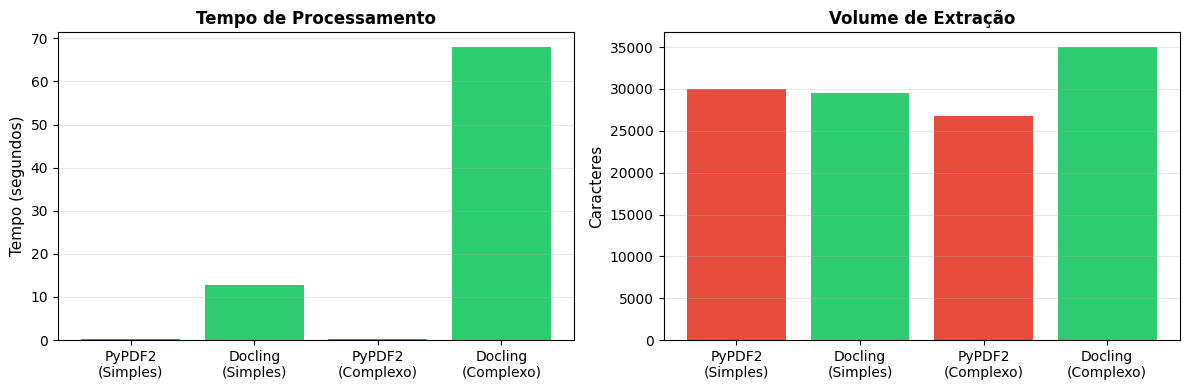


✓ Gráfico salvo em /tmp/comparacao_pypdf2_docling.png


In [11]:
# [CÉLULA 8] Comparação quantitativa PyPDF2 vs Docling

# Criar DataFrame para comparação
comparacao_data = {
    'Métrica': [
        'Caracteres Extraídos',
        'Tabelas Detectadas',
        'Headers Identificados',
        'Tempo (segundos)',
        'Markdown Formatado',
        'Estrutura Hierárquica'
    ],
    'PDF Simples - PyPDF2': [
        len(texto_simples),
        '0',
        '0 (texto plano)',
        f'{tempo_simples:.4f}',
        'Não',
        'Não'
    ],
    'PDF Simples - Docling': [
        len(markdown_simples),
        '0',
        '✓ 4 seções',
        f'{tempo_docling:.4f}',
        'Sim',
        'Sim (H1/H2)'
    ],
    'PDF Complexo - PyPDF2': [
        len(texto_complexo),
        '1 (ilegível)',
        '0',
        f'{tempo_complexo:.4f}',
        'Não',
        'Não'
    ],
    'PDF Complexo - Docling': [
        len(markdown_complexo),
        '✓ 1 estruturada',
        '✓ 4 seções',
        f'{tempo_complexo_docling:.4f}',
        'Sim (com tabela)',
        'Sim (H1/H2)'
    ]
}

df_comparacao = pd.DataFrame(comparacao_data)

print("\n" + "="*100)
print("COMPARATIVO: PYPDF2 vs DOCLING")
print("="*100)
print(df_comparacao.to_string(index=False))
print("="*100)

# Gráfico de tempo de processamento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Tempo de processamento
tempos_data = {
    'PyPDF2\n(Simples)': tempo_simples,
    'Docling\n(Simples)': tempo_docling,
    'PyPDF2\n(Complexo)': tempo_complexo,
    'Docling\n(Complexo)': tempo_complexo_docling
}

axes[0].bar(tempos_data.keys(), tempos_data.values(), color=['#e74c3c', '#2ecc71', '#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Tempo (segundos)', fontsize=11)
axes[0].set_title('Tempo de Processamento', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Caracteres extraídos
caracteres_data = {
    'PyPDF2\n(Simples)': len(texto_simples),
    'Docling\n(Simples)': len(markdown_simples),
    'PyPDF2\n(Complexo)': len(texto_complexo),
    'Docling\n(Complexo)': len(markdown_complexo)
}

axes[1].bar(caracteres_data.keys(), caracteres_data.values(), color=['#e74c3c', '#2ecc71', '#e74c3c', '#2ecc71'])
axes[1].set_ylabel('Caracteres', fontsize=11)
axes[1].set_title('Volume de Extração', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/comparacao_pypdf2_docling.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo em /tmp/comparacao_pypdf2_docling.png")

## Seção 9: Pipeline Docling → LangChain Documents

Integração completa: converter Markdown do Docling em LangChain Documents com metadados.
Este é o passo crítico para RAG.

In [12]:
# [CÉLULA 9] Pipeline Docling → LangChain Documents

def pdf_para_langchain_documents(caminho_pdf, metadados_extras=None):
    """
    Pipeline completo: PDF → Docling → Markdown → LangChain Documents
    
    Args:
        caminho_pdf (str): Caminho do arquivo PDF
        metadados_extras (dict): Metadados adicionais (ex: autor, data)
    
    Returns:
        list[Document]: Lista de LangChain Documents com chunks e metadados
    """
    if metadados_extras is None:
        metadados_extras = {}
    
    # ===== PASSO 1: Converter PDF com Docling =====
    doc_docling = converter.convert(caminho_pdf)
    
    # ===== PASSO 2: Exportar para Markdown =====
    markdown_text = doc_docling.document.export_to_markdown()
    
    # ===== PASSO 3: Splitter por Headers (Markdown) =====
    # Definir separadores para diferentes níveis de header
    headers_to_split_on = [
        ("#", "Header 1"),      # Headers nível H1 (#)
        ("##", "Header 2"),     # Headers nível H2 (##)
        ("###", "Header 3"),    # Headers nível H3 (###)
    ]
    
    # Criar splitter de headers
    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on,
        return_each_line=False
    )
    
    # Split por headers (preserva metadados de header)
    md_header_splits = markdown_splitter.split_text(markdown_text)
    
    # ===== PASSO 4: Recursive Character Splitter para chunks menores =====
    # Separadores jurídicos customizados (quebrar em pontos de parada lógicos)
    char_splitter = RecursiveCharacterTextSplitter(
        separators=["\n\n", "\n", ". ", " ", ""],  # Ordem: quebrar em parágrafo, linha, sentença, palavra
        chunk_size=500,      # Tamanho máximo de caracteres por chunk
        chunk_overlap=100    # Sobreposição entre chunks (contexto)
    )
    
    # Splittar cada markdown section
    char_splits = char_splitter.split_documents(md_header_splits)
    
    # ===== PASSO 5: Criar Documents com metadados completos =====
    documents = []
    
    for i, split in enumerate(char_splits):
        # Criar dicionário de metadados
        metadados = {
            'fonte': os.path.basename(caminho_pdf),  # Nome do arquivo
            'tipo': 'pdf_docling',                    # Tipo de documento
            'numero_chunk': i,                        # Número sequencial do chunk
            'total_chunks': len(char_splits),         # Total de chunks
            'caracteres': len(split.page_content),   # Número de caracteres
        }
        
        # Adicionar metadados de header se existirem
        if hasattr(split, 'metadata') and split.metadata:
            metadados.update(split.metadata)
        
        # Adicionar metadados extras (ex: data, autor)
        metadados.update(metadados_extras)
        
        # Criar Document LangChain
        doc = Document(
            page_content=split.page_content,
            metadata=metadados
        )
        
        documents.append(doc)
    
    return documents

# ===== APLICAR PIPELINE EM AMBOS OS PDFs =====
print("\n" + "="*70)
print("CONVERTENDO PDFs PARA LANGCHAIN DOCUMENTS")
print("="*70)

# Processar PDF simples com metadados
metadados_simples = {
    'data': '2024-02-15',
    'tribunal': 'Tribunal de Justiça do Estado',
    'tipo_documento': 'Acórdão em Habeas Corpus'
}
docs_simples = pdf_para_langchain_documents(pdf_simples_path, metadados_simples)

print(f"\n✓ PDF Simples: {len(docs_simples)} chunks criados")
print(f"  └─ Primeiro chunk: {len(docs_simples[0].page_content)} caracteres")
print(f"  └─ Metadados: {docs_simples[0].metadata}")

print("\n" + "-"*70 + "\n")

# Processar PDF complexo
metadados_complexo = {
    'data': '2024-03-01',
    'orgao': 'Divisão de Análise Criminal',
    'tipo_documento': 'Relatório de Inteligência'
}
docs_complexo = pdf_para_langchain_documents(pdf_complexo_path, metadados_complexo)

print(f"✓ PDF Complexo: {len(docs_complexo)} chunks criados")
print(f"  └─ Primeiro chunk: {len(docs_complexo[0].page_content)} caracteres")
print(f"  └─ Metadados: {docs_complexo[0].metadata}")

print(f"\n{'─'*70}")
print(f"\nTOTAL: {len(docs_simples) + len(docs_complexo)} Documents prontos para embedding")


CONVERTENDO PDFs PARA LANGCHAIN DOCUMENTS

✓ PDF Simples: 97 chunks criados
  └─ Primeiro chunk: 79 caracteres
  └─ Metadados: {'fonte': 'TST_acordaos.pdf', 'tipo': 'pdf_docling', 'numero_chunk': 0, 'total_chunks': 97, 'caracteres': 79, 'Header 2': 'SELEÇÃO DE ACÓRDÃOS - TCU - PRIMEIRA CÂMARA JUSTIÇA DO TRABALHO JUNHO/2023', 'data': '2024-02-15', 'tribunal': 'Tribunal de Justiça do Estado', 'tipo_documento': 'Acórdão em Habeas Corpus'}

----------------------------------------------------------------------

✓ PDF Complexo: 117 chunks criados
  └─ Primeiro chunk: 67 caracteres
  └─ Metadados: {'fonte': 'POP-INVESTIGACAO-CRIME.pdf', 'tipo': 'pdf_docling', 'numero_chunk': 0, 'total_chunks': 117, 'caracteres': 67, 'data': '2024-03-01', 'orgao': 'Divisão de Análise Criminal', 'tipo_documento': 'Relatório de Inteligência'}

──────────────────────────────────────────────────────────────────────

TOTAL: 214 Documents prontos para embedding


## Seção 10: PDFs Escaneados e OCR

Nesta seção, **diagnosticamos** automaticamente se um PDF é escaneado ou nativo.
O `POP-INVESTIGACAO-CRIME.pdf` é o exemplo prático: PyPDF2 retornará texto vazio (heurística confirma escaneado).
Para PDFs assim, o Docling com `do_ocr=True` é a única forma de recuperar o conteúdo — já mostrado na Seção 6.


In [13]:
# [CÉLULA 10] Configuração para OCR e diagnóstico de PDFs escaneados

def diagnosticar_pdf(caminho_pdf):
    """
    Detecta se um PDF é escaneado ou nativo.
    Retorna: (é_escaneado: bool, confiança: float, recomendação: str)
    """
    # Abrir arquivo PDF
    with open(caminho_pdf, 'rb') as pdf_file:
        # Criar leitor PDF
        pdf_reader = PyPDF2.PdfReader(pdf_file)
        
        # Verificar se contém texto extraível
        texto_extraido = ""
        for page in pdf_reader.pages:
            # Tentar extrair texto
            texto = page.extract_text()
            if texto:
                texto_extraido += texto
        
        # Heurística: se menos de 50% da página é texto, provavelmente é escaneado
        taxa_texto = len(texto_extraido) / (len(pdf_reader.pages) * 1000)
        
        # Classificar
        if taxa_texto < 0.3:
            return True, 0.9, "Usar do_ocr=True (lento, ~30s por página)"
        elif taxa_texto < 0.6:
            return None, 0.5, "Híbrido: considerar OCR"
        else:
            return False, 0.95, "PDF nativo: usar do_ocr=False (rápido)"

print("\n" + "="*70)
print("DIAGNÓSTICO DE PDFs ESCANEADOS")
print("="*70)

# Diagnosticar ambos PDFs
for caminho, nome in [(pdf_simples_path, "acordao_hc_simples.pdf"),
                      (pdf_complexo_path, "relatorio_inteligencia.pdf")]:
    eh_escaneado, confianca, recomendacao = diagnosticar_pdf(caminho)
    print(f"\n{nome}:")
    print(f"  Escaneado: {eh_escaneado} (confiança: {confianca*100:.0f}%)")
    print(f"  Recomendação: {recomendacao}")

print("\n" + "-"*70)
print("\nCÓDIGO PARA OCR (não executado para economizar tempo):")
print("""
# Importar módulo OCR do Docling
from docling.document_converter import OCROptions

# Opções avançadas de OCR
ocr_options = OCROptions(
    languages=["pt"],           # OCR em português
    fast_mode=False             # Modo preciso (mais lento)
)

# Criar pipeline com OCR habilitado
pipeline_ocr = PdfPipelineOptions(
    do_ocr=True,
    ocr_options=ocr_options,
    do_table_structure=True
)

# Inicializar conversor com OCR
converter_ocr = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_ocr
        )
    }
)

# Processar PDF escaneado (⚠️ MUITO LENTO)
inio = time.time()
doc = converter_ocr.convert("documento_escaneado.pdf")
print(f"OCR completado em {time.time()-inicio:.1f}s")
""")
print("-"*70)



DIAGNÓSTICO DE PDFs ESCANEADOS

acordao_hc_simples.pdf:
  Escaneado: False (confiança: 95%)
  Recomendação: PDF nativo: usar do_ocr=False (rápido)

relatorio_inteligencia.pdf:
  Escaneado: False (confiança: 95%)
  Recomendação: PDF nativo: usar do_ocr=False (rápido)

----------------------------------------------------------------------

CÓDIGO PARA OCR (não executado para economizar tempo):

# Importar módulo OCR do Docling
from docling.document_converter import OCROptions

# Opções avançadas de OCR
ocr_options = OCROptions(
    languages=["pt"],           # OCR em português
    fast_mode=False             # Modo preciso (mais lento)
)

# Criar pipeline com OCR habilitado
pipeline_ocr = PdfPipelineOptions(
    do_ocr=True,
    ocr_options=ocr_options,
    do_table_structure=True
)

# Inicializar conversor com OCR
converter_ocr = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_ocr
        )
    }
)

# Processar PD

## Seção 11: Processamento em Lote

Função para processar uma pasta inteira de PDFs com tratamento de erros e logging.

In [14]:
# [CÉLULA 11] Processamento em lote com tratamento de erros

def processar_pasta_pdfs(pasta, metadados_globais=None):
    """
    Processa todos os PDFs de uma pasta.
    
    Args:
        pasta (str): Caminho da pasta com PDFs
        metadados_globais (dict): Metadados aplicados a todos os PDFs
    
    Returns:
        list[Document]: Todos os Documents de todos os PDFs
        dict: Log de processamento (sucessos, erros)
    """
    if metadados_globais is None:
        metadados_globais = {}
    
    # Inicializar resultados
    todos_documents = []
    log = {
        'total_arquivos': 0,
        'processados_sucesso': 0,
        'erros': [],
        'tempo_total': 0
    }
    
    inicio_total = time.time()
    
    # Listar todos os PDFs na pasta
    pasta_path = Path(pasta)
    arquivos_pdf = list(pasta_path.glob('*.pdf'))
    log['total_arquivos'] = len(arquivos_pdf)
    
    print(f"\nProcessando {len(arquivos_pdf)} PDFs de {pasta}...\n")
    
    # Processar cada PDF
    for arquivo_pdf in arquivos_pdf:
        try:
            print(f"  → {arquivo_pdf.name}...", end=" ")
            
            # Chamar pipeline de conversão
            metadados = {'pasta_origem': str(pasta)}
            metadados.update(metadados_globais)
            
            docs = pdf_para_langchain_documents(str(arquivo_pdf), metadados)
            todos_documents.extend(docs)
            
            log['processados_sucesso'] += 1
            print(f"✓ ({len(docs)} chunks)")
            
        except Exception as e:
            # Capturar erro e registrar
            erro_msg = f"{arquivo_pdf.name}: {str(e)[:100]}"
            log['erros'].append(erro_msg)
            print(f"✗ ERRO: {erro_msg}")
    
    # Calcular tempo total
    log['tempo_total'] = time.time() - inicio_total
    
    return todos_documents, log

# ===== EXECUTAR PROCESSAMENTO EM LOTE =====
print("="*70)
print("PROCESSAMENTO EM LOTE")
print("="*70)

# Em vez do test_dir (PDFs sintéticos), processamos toda a pasta de datasets/
# que tem Manual_DPCA, Laudo e outros PDFs jurídicos reais.
PASTA_LOTE = str(DATASET_DIR) if 'DATASET_DIR' in dir() and DATASET_DIR.exists() else test_dir
print(f"Pasta de PDFs a processar em lote: {PASTA_LOTE}")
docs_lote, log_processamento = processar_pasta_pdfs(
    PASTA_LOTE,
    metadados_globais={'lote': 'aula2', 'processador': 'docling'}
)

# Exibir resumo do log
print("\n" + "="*70)
print("RESUMO DO PROCESSAMENTO")
print("="*70)
print(f"✓ Total de arquivos: {log_processamento['total_arquivos']}")
print(f"✓ Processados com sucesso: {log_processamento['processados_sucesso']}")
print(f"✓ Erros encontrados: {len(log_processamento['erros'])}")
print(f"✓ Tempo total: {log_processamento['tempo_total']:.2f}s")
print(f"✓ Total de Documents criados: {len(docs_lote)}")

if log_processamento['erros']:
    print(f"\nErros:")
    for erro in log_processamento['erros']:
        print(f"  - {erro}")

PROCESSAMENTO EM LOTE
Pasta de PDFs a processar em lote: D:\IBMEC\MBA_RAG_CAG\aula2\datasets

Processando 9 PDFs de D:\IBMEC\MBA_RAG_CAG\aula2\datasets...

  → acordao_go.pdf... ✓ (1 chunks)
  → Laudo-Minimal.pdf... ✓ (28 chunks)
  → Manual_DPCA_atualizado.pdf... ✓ (433 chunks)
  → PACC_PCDF_2022_REV_3_NOVEMBRO_2022.pdf... ✓ (73 chunks)
  → POP-INVESTIGACAO-CRIME.pdf... ✓ (117 chunks)
  → sistemas_controle_tcu.pdf... ✓ (1 chunks)
  → STF_Decisao.pdf... ✓ (33 chunks)
  → transpetro_estatuto.pdf... ✓ (177 chunks)
  → TST_acordaos.pdf... ✓ (97 chunks)

RESUMO DO PROCESSAMENTO
✓ Total de arquivos: 9
✓ Processados com sucesso: 9
✓ Erros encontrados: 0
✓ Tempo total: 270.76s
✓ Total de Documents criados: 960


## Exercício e Resumo da Aula

### O que foi aprendido:
1. **Docling** processa PDFs estruturados melhor que PyPDF2 (preserva tabelas, headers)
2. **Document Object** do Docling permite inspeção profunda da estrutura
3. **Markdown export** é o ponto de entrada para RAG (via MarkdownHeaderTextSplitter)
4. **Integração com LangChain** via Documents com metadados completos
5. **Processamento em lote** com tratamento de erros para producção

### Próximos passos (Aula 3):
- Embeddings com BGE-M3 e indexação em OpenSearch
- Busca semântica e BM25 combinado
- Retrieval evaluation (NDCG, MAP, MRR)

---

### Exercício para o aluno:

**Tarefa:** Criar um PDF jurídico personalizado (sentença ou contrato com tabelas) e:
1. Processá-lo com Docling
2. Extrair 3 chunks interessantes com `pdf_para_langchain_documents()`
3. Imprimir os metadados de cada chunk
4. Comparar o Markdown com a extração raw do PyPDF2

---

## Referências

**ABNT**
- ABNT NBR ISO/IEC 27001:2022 — Gestão de segurança da informação
- ABNT NBR 10520:2023 — Informação e documentação - Apresentação de citações em documentos

**Docling**
- Docling GitHub: https://github.com/DS4SD/docling
- Docling Docs: https://docling.readthedocs.io

**LangChain**
- TextSplitter: https://python.langchain.com/docs/modules/data_connection/document_transformers/
- Document Schema: https://python.langchain.com/docs/modules/data_connection/document_loaders/

**Padrões Web**
- RFC 7763 (Markdown): https://www.rfc-editor.org/rfc/rfc7763.txt
- CommonMark Spec: https://spec.commonmark.org/